# DateTime Feature - Cyclical

In [2]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'month': range(1, 13)
})

df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

print(df)

    month     month_sin     month_cos
0       1  5.000000e-01  8.660254e-01
1       2  8.660254e-01  5.000000e-01
2       3  1.000000e+00  6.123234e-17
3       4  8.660254e-01 -5.000000e-01
4       5  5.000000e-01 -8.660254e-01
5       6  1.224647e-16 -1.000000e+00
6       7 -5.000000e-01 -8.660254e-01
7       8 -8.660254e-01 -5.000000e-01
8       9 -1.000000e+00 -1.836970e-16
9      10 -8.660254e-01  5.000000e-01
10     11 -5.000000e-01  8.660254e-01
11     12 -2.449294e-16  1.000000e+00


🔍 Key Observation

| Month | sin  | cos   |
| ----- | ---- | ----- |
| 1     | ~0.5 | ~0.87 |
| 6     | 0    | -1    |
| 12    | 0    | 1     |


```bash
👉 Notice:

Month 12 → (0,1)
Month 1 → (~0.5, ~0.87)

👉 They are close in circle space ✅

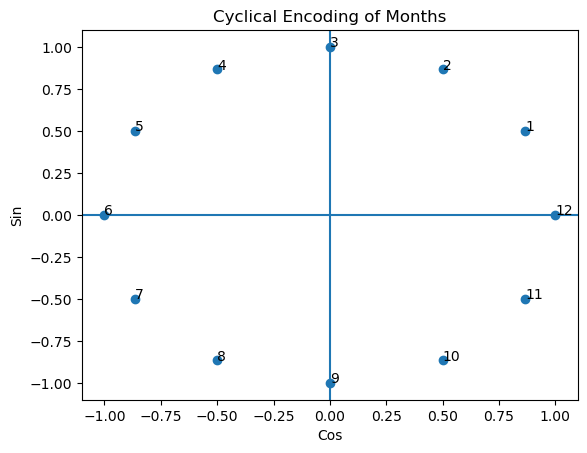

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['month_cos'], df['month_sin'])

for i, txt in enumerate(df['month']):
    plt.annotate(txt, (df['month_cos'][i], df['month_sin'][i]))

plt.title("Cyclical Encoding of Months")
plt.xlabel("Cos")
plt.ylabel("Sin")
plt.axhline(0)
plt.axvline(0)
plt.show()

```bash

🧠 What you’re seeing
Each month is converted into a point on a circle:

(month_sin, month_cos) → (y, x)
👉 So every month = a position on a unit circle


```bash
🔵 Think of a CLOCK 🕐 (best intuition)
Instead of months 1–12, imagine:

1 → 12 o’clock
3 → 3 o’clock
6 → 6 o’clock
9 → 9 o’clock

📊 Key Months Explained

```bash
📍 Month 3
sin = 1
cos ≈ 0
👉 Position:
TOP of circle (12 o’clock)

📍 Month 6
sin ≈ 0
cos = -1

👉 Position:
LEFT side (9 o’clock)

📍 Month 9
sin = -1
cos ≈ 0
👉 Position:
BOTTOM (6 o’clock)

📍 Month 12
sin ≈ 0
cos = 1

👉 Position:
RIGHT side (3 o’clock)

🔄 Why this matters

```bash
Look at: 
Month 12:
(-0, 1)

Month 1:
(0.5, 0.86)
👉 These are close in space ✅

But normal numbers:
12 → 1 = far ❌

👉 Model thinks:
12 is far from 1 ❌

If you use:
sin + cos
👉 Model understands:
December ≈ January ✅
